# Supervised Learning - Stage 4: Random Forest
**Goal:** Train a strong non-linear baseline with interpretable feature importances.

Random Forest is an ensemble of decision trees trained on random subsets of the data
and features (bagging). It is well suited to this dataset because:
- Handles mixed feature types (categorical codes + continuous) natively
- Captures non-linear feature interactions (e.g. speed limit AND wet road AND night)
- Provides feature importances directly from the tree structure
- Robust to outliers and does not require feature scaling

`RandomizedSearchCV` is used for hyperparameter tuning rather than full `GridSearchCV`.
With 180 fits over 14,646 SMOTE-resampled samples, a full grid would be prohibitively
slow. Randomised search samples a fixed number of parameter combinations, giving a good
approximation at a fraction of the compute cost.

In [11]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

def find_project_root(marker='config.yml'):
    current = Path().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Could not find {marker} in any parent directory')

ROOT_DIR = find_project_root()
NOTEBOOKS_DIR = ROOT_DIR / 'notebooks'

with open(ROOT_DIR / 'config.yml') as f:
    cfg = yaml.safe_load(f)

with open(NOTEBOOKS_DIR / 'notebook-config.yml') as f:
    nb_cfg = yaml.safe_load(f)

NB_CONFIG = {
    'figsize_wide':    nb_cfg['plotting']['figsize_wide'],
    'figsize_square':  nb_cfg['plotting']['figsize_square'],
    'palette':         nb_cfg['plotting']['palette'],
    'severity_labels': {int(k): v for k, v in nb_cfg['labels']['severity'].items()},
    'n_iter_search':   20,
}

sns.set_theme(style='whitegrid', palette=NB_CONFIG['palette'])
print(f'Project root: {ROOT_DIR}')
print('Configs loaded.')

Project root: C:\Users\abdul\Documents\SHU\AI 1\Sheffield-Road-Collision-Detection-Coursework
Configs loaded.


---
# 2. Load Stage 2 Outputs

In [12]:
with open(NOTEBOOKS_DIR / 'stage_outputs' / 'stage2.pkl', 'rb') as f:
    stage2 = pickle.load(f)

X_train = stage2['X_train_resampled']
y_train = stage2['y_train_resampled']
X_test  = stage2['X_test']
y_test  = stage2['y_test']

class_names = [NB_CONFIG['severity_labels'][c] for c in sorted(y_test.unique())]

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')
print(f'Classes:      {class_names}')

Training set: (14646, 28)
Test set:     (1465, 28)
Classes:      ['Fatal', 'Serious', 'Slight']


---
# 3. HyperParameter Tuning via RandomizedSearchCSV

In [13]:
rf_params = cfg['supervised']['models']['random_forest']

param_dist = {
    'n_estimators': rf_params['n_estimators'],
    'max_depth': rf_params['max_depth'],
    'min_samples_split': rf_params['min_samples_split'],
}

base_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=cfg['supervised']['random_state'],
    n_jobs=-1,
)

cv = StratifiedKFold(
    n_splits=cfg['supervised']['cv_folds'],
    shuffle=True,
    random_state=cfg['supervised']['random_state'],
)

search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=NB_CONFIG['n_iter_search'],
    scoring='f1_macro', # optimise for balanced per-class performance
    cv=cv,
    random_state=cfg['supervised']['random_state'],
    n_jobs=-1,
    verbose=1,
)

print(f'Running RandomizedSearchCV: {NB_CONFIG["n_iter_search"]} iterations × {cfg["supervised"]["cv_folds"]} folds...')
search.fit(X_train, y_train)

print(f'\nBest parameters:  {search.best_params_}')
print(f'Best macro F1 (CV): {search.best_score_:.4f}')

Running RandomizedSearchCV: 20 iterations × 5 folds...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters:  {'n_estimators': 300, 'min_samples_split': 2, 'max_depth': None}
Best macro F1 (CV): 0.9221


In [14]:
cv_results = pd.DataFrame(search.cv_results_)
cv_results_clean = cv_results[
    ['param_n_estimators', 'param_max_depth', 'param_min_samples_split',
     'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score').head(10)

cv_results_clean.columns = ['n_estimators', 'max_depth', 'min_samples_split',
                             'mean_macro_f1', 'std', 'rank']
print('Top 10 parameter combinations:')
cv_results_clean

Top 10 parameter combinations:


,n_estimators,max_depth,min_samples_split,mean_macro_f1,std,rank
14,300,None,2,0.922148,0.003563,1
5,200,None,5,0.918416,0.002659,2
3,100,None,5,0.915387,0.002792,3
16,200,20,2,0.913035,0.005377,4
0,300,None,10,0.907830,0.001832,5
6,100,20,5,0.907671,0.003357,6
11,200,None,10,0.907574,0.002325,7
2,300,20,10,0.900041,0.004336,8
18,300,10,2,0.826286,0.010532,9
10,100,10,2,0.823467,0.011314,10


---
# 4. Evaluate Best Model on Test Set

In [15]:
rf_model = search.best_estimator_
y_pred   = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_per_class = f1_score(y_test, y_pred, average=None)

print(f'Accuracy:          {accuracy:.4f}')
print(f'Weighted F1:       {f1_weighted:.4f}')
print(f'Macro F1:          {f1_macro:.4f}')
print()
print('Per-class F1:')
for cls, f1 in zip(sorted(y_test.unique()), f1_per_class, strict=False):
    print(f'  {NB_CONFIG["severity_labels"][cls]:8s}: {f1:.4f}')

Accuracy:          0.7863
Weighted F1:       0.7590
Macro F1:          0.3721

Per-class F1:
  Fatal   : 0.0714
  Serious : 0.1652
  Slight  : 0.8797


In [16]:
print('Classification Report:')
print(classification_report(
    y_test, y_pred,
    target_names=class_names,
    digits=4
))

Classification Report:
              precision    recall  f1-score   support

       Fatal     0.1111    0.0526    0.0714        19
     Serious     0.2320    0.1283    0.1652       226
      Slight     0.8430    0.9197    0.8797      1220

    accuracy                         0.7863      1465
   macro avg     0.3954    0.3669    0.3721      1465
weighted avg     0.7392    0.7863    0.7590      1465



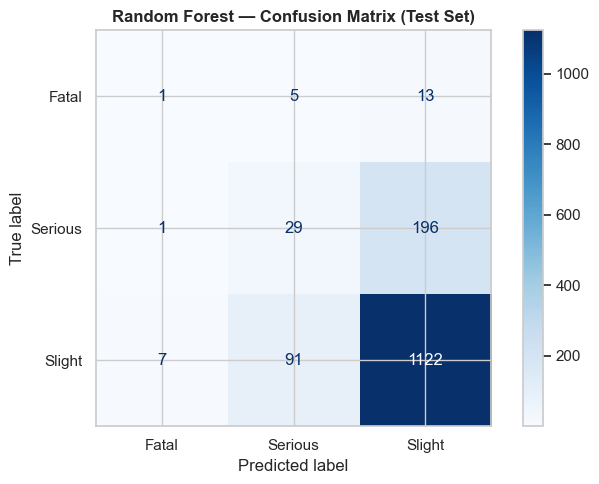


Fatal correctly identified:   1 / 19 (5.3%)
Serious correctly identified: 29 / 226 (12.8%)
Slight correctly identified:  1122 / 1220 (92.0%)


In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')

ax.set_title('Random Forest — Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nFatal correctly identified:   {cm[0,0]} / {cm[0].sum()} ({cm[0,0]/cm[0].sum():.1%})')
print(f'Serious correctly identified: {cm[1,1]} / {cm[1].sum()} ({cm[1,1]/cm[1].sum():.1%})')
print(f'Slight correctly identified:  {cm[2,2]} / {cm[2].sum()} ({cm[2,2]/cm[2].sum():.1%})')

---
# 5. Feature Importances

Random Forest computes feature importances as the mean decrease in impurity (Gini)
across all trees - giving a direct measure of each feature's contribution to predictions.

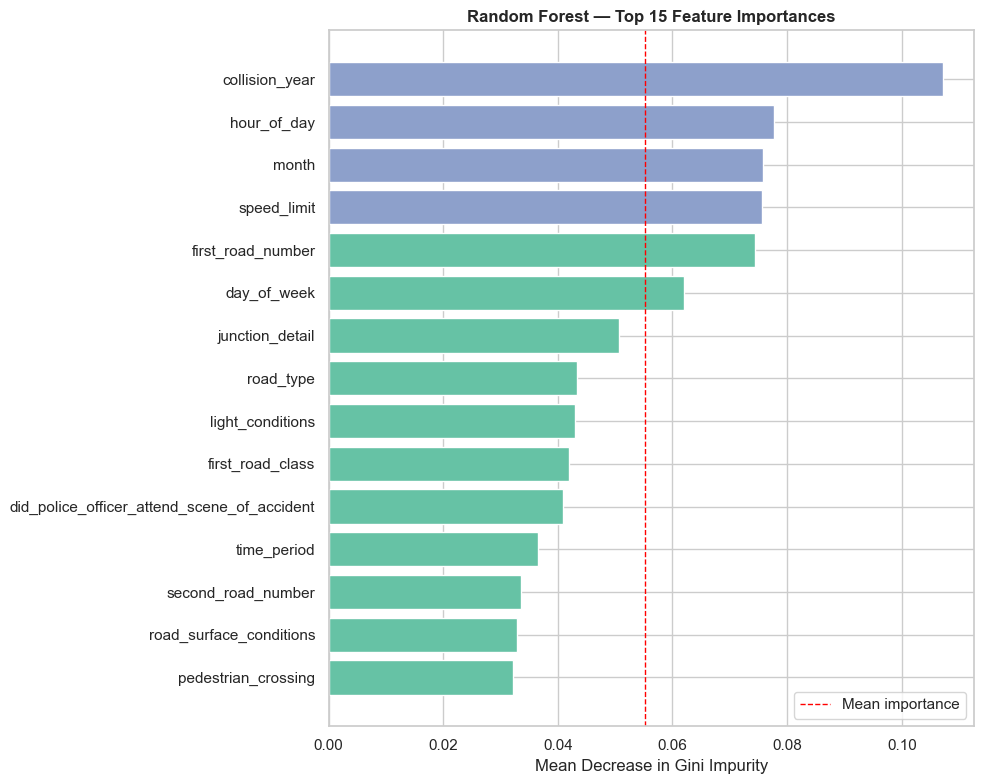


Top 5 most important features:
  collision_year                          : 0.1072
  hour_of_day                             : 0.0777
  month                                   : 0.0758
  speed_limit                             : 0.0756
  first_road_number                       : 0.0744


In [18]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

top_n = 15
top_importances = importances.tail(top_n)

fig, ax = plt.subplots(figsize=tuple(NB_CONFIG['figsize_square']))
colors = [
    sns.color_palette(NB_CONFIG['palette'])[0]
    if v < top_importances.quantile(0.75)
    else sns.color_palette(NB_CONFIG['palette'])[2]
    for v in top_importances
]
ax.barh(top_importances.index, top_importances.values, color=colors)
ax.set_xlabel('Mean Decrease in Gini Impurity')
ax.set_title(f'Random Forest — Top {top_n} Feature Importances',
             fontsize=12, fontweight='bold')
ax.axvline(top_importances.mean(), color='red', linestyle='--',
           linewidth=1, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
for feat, val in importances.tail(5).sort_values(ascending=False).items():
    print(f'  {feat:40s}: {val:.4f}')

---
# 6. Comparison with Logistic Regression Baseline 

In [19]:
with open(NOTEBOOKS_DIR / 'stage_outputs' / 'stage3.pkl', 'rb') as f:
    stage3 = pickle.load(f)

comparison = pd.DataFrame([
    {
        'Model':       stage3['model_name'],
        'Accuracy':    stage3['accuracy'],
        'Weighted F1': stage3['f1_weighted'],
        'Macro F1':    stage3['f1_macro'],
        'Fatal F1':    stage3['f1_per_class'][0],
        'Serious F1':  stage3['f1_per_class'][1],
        'Slight F1':   stage3['f1_per_class'][2],
    },
    {
        'Model':       'Random Forest',
        'Accuracy':    accuracy,
        'Weighted F1': f1_weighted,
        'Macro F1':    f1_macro,
        'Fatal F1':    f1_per_class[0],
        'Serious F1':  f1_per_class[1],
        'Slight F1':   f1_per_class[2],
    },
]).set_index('Model').round(4)

print('Model comparison so far:')
comparison

Model comparison so far:


,Accuracy,Weighted F1,Macro F1,Fatal F1,Serious F1,Slight F1
Model,,,,,,
Logistic Regression,0.5147,0.5949,0.3083,0.0433,0.2060,0.6756
Random Forest,0.7863,0.7590,0.3721,0.0714,0.1652,0.8797


**Next: Stage 5 = XGBoost.**

In [20]:
output_path = NOTEBOOKS_DIR / 'stage_outputs' / 'stage4.pkl'

with open(output_path, 'wb') as f:
    pickle.dump({
        'model':        rf_model,
        'y_pred':       y_pred,
        'y_test':       y_test,
        'accuracy':     accuracy,
        'f1_weighted':  f1_weighted,
        'f1_macro':     f1_macro,
        'f1_per_class': f1_per_class,
        'model_name':   'Random Forest',
        'best_params':  search.best_params_,
    }, f)

print(f'Stage 4 outputs saved to: {output_path}')

Stage 4 outputs saved to: C:\Users\abdul\Documents\SHU\AI 1\Sheffield-Road-Collision-Detection-Coursework\notebooks\stage_outputs\stage4.pkl
